In [1]:
import os
import numpy as np
from glob import glob
from collections import defaultdict
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from dtwalign import dtw

In [2]:
# Config
SPLIT_FILE = "../../my_rps_dataset/splits_noval.json"
OBS_RATIOS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
data_dir_list = ["../../my_rps_dataset/features_coords", 
                 "../../my_rps_dataset/features_angles"]
results_all = {'OpenEndDTW': {}, 'SoftDTW': {}} 

Utils

In [ ]:
def load_landmarks(path):
    """Load npz containing landmarks."""
    data = np.load(path)
    return data["landmarks"]  # shape (T, 21, 3)

def frame_to_vector(lm_frame):
    """Flatten keypoints from (K,3) -> (3K,)."""
    return lm_frame.reshape(-1)

def sequence_to_feature_matrix(lm_seq, use_vel=False):
    """Convert sequence of landmarks (T,K,D) into matrix (T, D*K)."""

    # Check if lm_seq is actually 3D
    if len(lm_seq.shape) == 2: 
        return lm_seq

    T, K, D = lm_seq.shape
    X = np.stack([frame_to_vector(lm_seq[t]) for t in range(T)], axis=0)  # (T, K*D)
    if use_vel:
        V = np.zeros_like(X)
        V[1:] = X[1:] - X[:-1]
        X = np.concatenate([X, V], axis=1)  # (T, 2*K*D)
    return X

# Dataset loading
def load_splits(split_file, data_dir):
    with open(split_file, "r") as f:
        splits = json.load(f)
    datasets = {}
    
    for split_name, file_list in splits.items():
        samples = []
        for fname in file_list:
            path = os.path.join(data_dir, fname)
            label = fname.split("_")[0]  # class from filename prefix
            lm = load_landmarks(path)
            samples.append({"id": fname, "label": label, "landmarks": lm})
        datasets[split_name] = samples
    return datasets

# TODO: move to /modules
def accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(y_true == y_pred))

## All Features: 3D Coords (normalized, scaled and rotation invariant), Angles (MCP as center), Angles (Wrist as center)

In [ ]:
if __name__ == "__main__":

    for DATA_DIR in data_dir_list:
        print(DATA_DIR)
        datasets = load_splits(SPLIT_FILE, DATA_DIR)
        train_set, test_set = datasets["train"], datasets["test"]

        # Precompute features for train set
        train_feats = []
        for s in train_set:
            X = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
            X = np.nan_to_num(X)
            train_feats.append((X, s["label"], s["id"]))

        results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

        for r in OBS_RATIOS: 
        
            for s in test_set:
                Xfull = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
                Xfull = np.nan_to_num(Xfull)
                
                T = Xfull.shape[0]            
                t_obs = max(1, int(np.round(T * r / 100.0)))
                prefix = Xfull[:t_obs]

                dists = []
                for Xtr, lab, tid in train_feats:
                    c = dtw(prefix, Xtr, open_begin=False, open_end=True)
                    dists.append((c.normalized_distance, lab))
                    # dists.append((c.distance, lab))

                dists.sort(key=lambda x: x[0])
                pred = dists[0][1]
                # margin = distance to 2nd nearest
                conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0

                results[r]["y_true"].append(s["label"])
                results[r]["y_pred"].append(pred)
                results[r]["conf"].append(conf)
            
            acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
            results[r]["acc"] = acc
            print(f"{r}% observed: {acc:.3f}")

        data_id = DATA_DIR.split('_')[-1]
        results_all['OpenEndDTW'][data_id] = results

### Plot

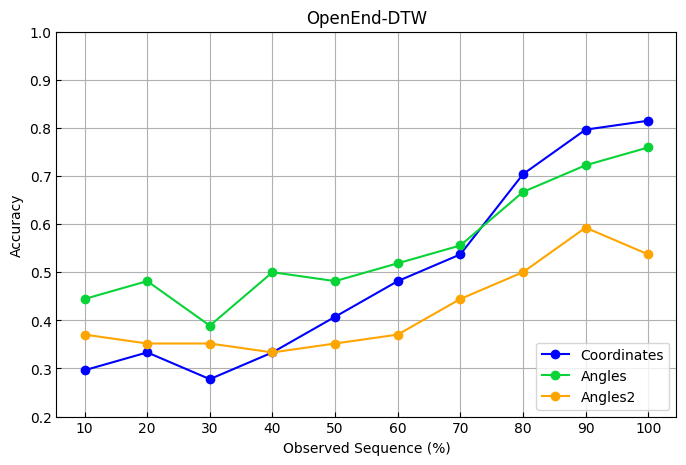

In [ ]:
import matplotlib.pyplot as plt

acc_coords = [results_all['OpenEndDTW']['coords'][r]['acc'] for r in OBS_RATIOS]
acc_angles = [results_all['OpenEndDTW']['angles'][r]['acc'] for r in OBS_RATIOS]

plt.figure(figsize=(8,5))
config = {'Coordinates': {'acc': acc_coords,
                          'color': 'blue'}, 
          'Angles': {'acc': acc_angles,
                     'color': '#08D337'}}

for label, res in config.items():
    plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

plt.xlabel("Observed Sequence (%)")
plt.ylabel("Accuracy")
plt.title("OpenEnd-DTW")
plt.grid()
plt.legend(loc='lower right')

plt.xticks(OBS_RATIOS)
plt.ylim(0.2, 1)

plt.tick_params(axis='both', direction='in', which='both')
plt.show()

### Soft-DTW

In [ ]:
import sys
sys.path.append('../../pytorch-softdtw-cuda')
from soft_dtw_cuda import SoftDTW
import torch
import numpy as np

# Soft-DTW classification
def soft_dtw_classify():
    
    # Initialize Soft-DTW (use CPU to avoid CUDA issues)
    sdtw = SoftDTW(use_cuda=False, gamma=0.1)
    
    for DATA_DIR in data_dir_list:
        print(DATA_DIR)
        datasets = load_splits(SPLIT_FILE, DATA_DIR)
        train_set, test_set = datasets["train"], datasets["test"]

        # Precompute features for train set and convert to PyTorch tensors
        train_feats = []
        for s in train_set:
            X = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
            X = np.nan_to_num(X)
            X_tensor = torch.FloatTensor(X).unsqueeze(0)  # Add batch dimension
            train_feats.append((X_tensor, s["label"], s["id"]))

        results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

        for r in OBS_RATIOS:

            for s in test_set:
                Xfull = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
                Xfull = np.nan_to_num(Xfull)
                
                T = Xfull.shape[0]
                t_obs = max(1, int(np.round(T * r / 100.0)))
                prefix = Xfull[:t_obs]
                
                # Convert to PyTorch tensor
                prefix_tensor = torch.FloatTensor(prefix).unsqueeze(0)  # Add batch dimension

                dists = []
                for X_train_tensor, lab, tid in train_feats:
                    with torch.no_grad():  # No gradients needed for inference
                        soft_dtw_dist = sdtw(prefix_tensor, X_train_tensor)
                        distance = soft_dtw_dist.item()  # Convert to scalar
                    dists.append((distance, lab))

                # Find minimum distance prediction
                dists.sort(key=lambda x: x[0])
                pred = dists[0][1]
                
                # Compute confidence as margin between 1st and 2nd closest
                conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
                results[r]["y_true"].append(s["label"])
                results[r]["y_pred"].append(pred)
                results[r]["conf"].append(conf)
            
            acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
            results[r]["acc"] = acc
            print(f"{r}% observed: {acc:.3f}")

        data_id = DATA_DIR.split('_')[-1]
        results_all['SoftDTW'][data_id] = results
    
    return results_all

# Run the classification
soft_dtw_results = soft_dtw_classify()

../../my_rps_dataset/features_coords
10% observed: 0.333
20% observed: 0.278
30% observed: 0.296
40% observed: 0.352
50% observed: 0.444
60% observed: 0.574
70% observed: 0.667
80% observed: 0.778
90% observed: 0.815
100% observed: 0.852
../../my_rps_dataset/features_angles
10% observed: 0.278
20% observed: 0.352
30% observed: 0.315
40% observed: 0.352
50% observed: 0.537
60% observed: 0.648
70% observed: 0.796
80% observed: 0.852
90% observed: 0.907
100% observed: 0.870
../../my_rps_dataset/features_angles2
10% observed: 0.315
20% observed: 0.333
30% observed: 0.352
40% observed: 0.315
50% observed: 0.407
60% observed: 0.426
70% observed: 0.556
80% observed: 0.611
90% observed: 0.648
100% observed: 0.704


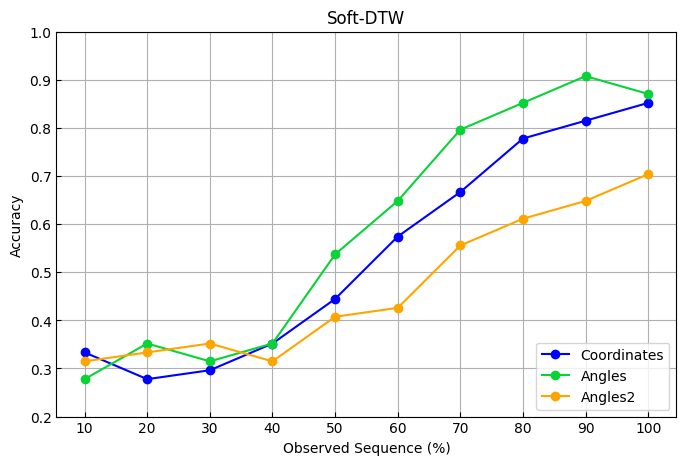

In [ ]:
import matplotlib.pyplot as plt

acc_coords = [soft_dtw_results['SoftDTW']['coords'][r]['acc'] for r in OBS_RATIOS]
acc_angles = [soft_dtw_results['SoftDTW']['angles'][r]['acc'] for r in OBS_RATIOS]

plt.figure(figsize=(8,5))
config = {'Coordinates': {'acc': acc_coords,
                          'color': 'blue'}, 
          'Angles': {'acc': acc_angles,
                     'color': '#08D337'}}   

for label, res in config.items():
    plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

plt.xlabel("Observed Sequence (%)")
plt.ylabel("Accuracy")
plt.title("Soft-DTW")
plt.grid()
plt.legend(loc='lower right')

plt.xticks(OBS_RATIOS)
plt.ylim(0.2, 1)
plt.tick_params(axis='both', direction='in', which='both')
plt.show()

### Compare DTW variants

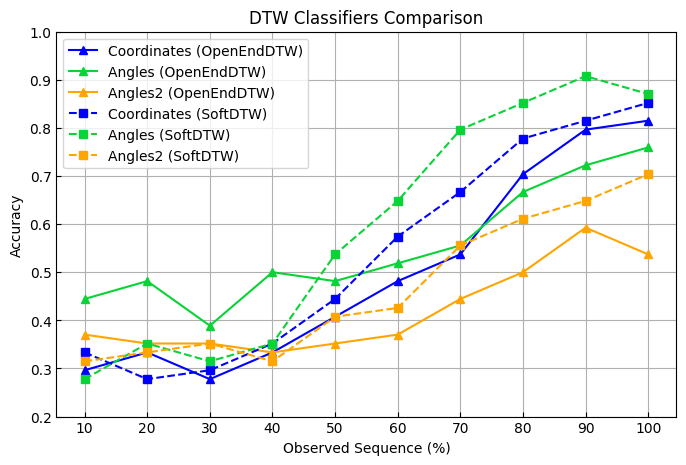

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
config = {'Coordinates': {'acc': None,
                          'color': 'blue', 
                          'config_OpenEndDTW': {'marker': '^', 'linestyle': 'solid'},
                          'config_SoftDTW': {'marker': 's', 'linestyle': '--'}, 
                        },    
          'Angles': {'acc': None,
                     'color': '#08D337',
                     'config_OpenEndDTW': {'marker': '^', 'linestyle': 'solid'},
                     'config_SoftDTW': {'marker': 's', 'linestyle': '--'}, 
                     }
        }

# Store legend handles for each combination
legend_handles = []
legend_labels = []

for clf_label in results_all.keys():
    acc_coords = [results_all[clf_label]['coords'][r]['acc'] for r in OBS_RATIOS]
    acc_angles = [results_all[clf_label]['angles'][r]['acc'] for r in OBS_RATIOS]
    
    config['Coordinates']['acc'] = acc_coords
    config['Angles']['acc'] = acc_angles

    for label, res in config.items():
        line, = plt.plot(OBS_RATIOS, res['acc'], color=res['color'], **res[f'config_{clf_label}'])
        legend_labels.append(f'{label} ({clf_label})')
        legend_handles.append(line)
        
        #for clf_label in results_all.keys():

plt.xlabel("Observed Sequence (%)")
plt.ylabel("Accuracy")
plt.title("DTW Classifiers Comparison")
plt.grid()

# Create legend with all combinations
plt.legend(legend_handles, legend_labels, loc='upper left')
plt.xticks(OBS_RATIOS)
plt.ylim(0.2, 1)
plt.tick_params(axis='both', direction='in', which='both')
plt.show()


## Cropped videos

In [24]:
if __name__ == "__main__":

    for DATA_DIR in data_dir_list:
        print(DATA_DIR)
        datasets = load_splits_cropped(SPLIT_FILE, DATA_DIR)
        train_set, test_set = datasets["train"], datasets["test"]
        print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")
        # Precompute features for train set
        train_feats = []
        for s in train_set:
            X = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
            X = np.nan_to_num(X)
            train_feats.append((X, s["label"], s["id"]))

        results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

        for r in OBS_RATIOS: 
        
            for s in test_set:
                Xfull = sequence_to_feature_matrix(s["landmarks"], use_vel=False)
                Xfull = np.nan_to_num(Xfull)
                
                T = Xfull.shape[0]            
                t_obs = max(1, int(np.round(T * r / 100.0)))
                prefix = Xfull[:t_obs]

                dists = []
                for Xtr, lab, tid in train_feats:
                    c = dtw(prefix, Xtr, open_begin=False, open_end=True)
                    dists.append((c.normalized_distance, lab))
                    # dists.append((c.distance, lab))

                dists.sort(key=lambda x: x[0])
                pred = dists[0][1]
                # margin = distance to 2nd nearest
                conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0

                results[r]["y_true"].append(s["label"])
                results[r]["y_pred"].append(pred)
                results[r]["conf"].append(conf)
            
            acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
            results[r]["acc"] = acc
            print(f"{r}% observed: {acc:.3f}")

        data_id = DATA_DIR.split('_')[-1]
        results_all['OpenEndDTW'][data_id] = results

../../my_rps_dataset/features_coords
Train samples: 22, Test samples: 8
10% observed: 0.250
20% observed: 0.250
30% observed: 0.250
40% observed: 0.375
50% observed: 0.375
60% observed: 0.375
70% observed: 0.500
80% observed: 0.625
90% observed: 0.750
100% observed: 0.875
../../my_rps_dataset/features_angles
Train samples: 22, Test samples: 8
10% observed: 0.375
20% observed: 0.375
30% observed: 0.375
40% observed: 0.500
50% observed: 0.500
60% observed: 0.500
70% observed: 0.625
80% observed: 0.750
90% observed: 1.000
100% observed: 1.000


KeyError: 'coords'

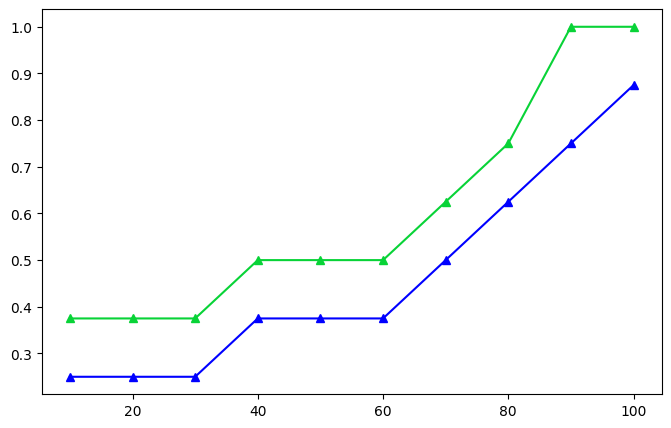

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
config = {'Coordinates': {'acc': None,
                          'color': 'blue', 
                          'config_OpenEndDTW': {'marker': '^', 'linestyle': 'solid'},
                          'config_SoftDTW': {'marker': 's', 'linestyle': '--'}, 
                        },    
          'Angles': {'acc': None,
                     'color': '#08D337',
                     'config_OpenEndDTW': {'marker': '^', 'linestyle': 'solid'},
                     'config_SoftDTW': {'marker': 's', 'linestyle': '--'}, 
                     }
        }

# Store legend handles for each combination
legend_handles = []
legend_labels = []

for clf_label in results_all.keys():
    acc_coords = [results_all[clf_label]['coords'][r]['acc'] for r in OBS_RATIOS]
    acc_angles = [results_all[clf_label]['angles'][r]['acc'] for r in OBS_RATIOS]
    
    config['Coordinates']['acc'] = acc_coords
    config['Angles']['acc'] = acc_angles

    for label, res in config.items():
        line, = plt.plot(OBS_RATIOS, res['acc'], color=res['color'], **res[f'config_{clf_label}'])
        legend_labels.append(f'{label} ({clf_label})')
        legend_handles.append(line)
        
        #for clf_label in results_all.keys():

plt.xlabel("Observed Sequence (%)")
plt.ylabel("Accuracy")
plt.title("DTW Classifiers Comparison")
plt.grid()

# Create legend with all combinations
plt.legend(legend_handles, legend_labels, loc='upper left')
plt.xticks(OBS_RATIOS)
plt.ylim(0.2, 1)
plt.tick_params(axis='both', direction='in', which='both')
plt.show()
